In [1]:
# === CONFIGURATION ===

# 1. Environment Settings
HEIGHT = 6
WIDTH = 6
NUM_AGENTS = 2
SPAWN_PROB = 0.05
DESPAWN_PROB = 0.09

# 2. Model Hyperparameters 
# Extracted from your SLURM script (applied to both CNN tasks)
CNN_CONV_CHANNELS = [32, 64]
CNN_HEAD_HIDDEN_DIM = 128
CNN_HEAD_NUM_LAYERS = 3
CNN_KERNEL_SIZE = 3

# 3. File Paths
# Using the specific resume steps you requested:
PATH_CENTRALIZED = "cen_cnn/model_step9400000.pt"

# Decentralized: 16.05M steps
PATH_DECENTRALIZED_AG0 = "decen_cnn_-12_reward/model_agent0_step16050000.pt" # decen_cnn_-12_reward/model_agent0_step16050000.pt
PATH_DECENTRALIZED_AG1 = "decen_cnn_-12_reward/model_agent1_step16050000.pt" # decen_cnn_-12_reward/model_agent1_step16050000.pt

# 4. Analysis Settings
TRAJECTORY_STEPS = 10000

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import sys
import ast

# Adjust path to find local modules
sys.path.append("../") 

from models.value_cnn_new import ValueCNNCentralizedStandard, ValueCNNDecentralizedStandard
from tadd_helpers.env_functions import init_empty_state, spawn_apples, despawn_apples, State
from tadd_helpers.eval_functions import nearest_policy
from orchard.environment import MoveAction

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running analysis on: {DEVICE}")

--- PyTorch is configured to use: cuda ---
Running analysis on: cuda


In [3]:
# =============================================================================
# PHASE 1: LOAD MODELS
# =============================================================================
def load_models():
    print(f"Loading models...")
    
    # --- 1. Load Centralized Model (Standard CNN) ---
    cent_model = ValueCNNCentralizedStandard(
        height=HEIGHT, width=WIDTH, lr=0.0, discount=0.99,
        hidden_dim=CNN_HEAD_HIDDEN_DIM, 
        num_layers=CNN_HEAD_NUM_LAYERS, 
        conv_channels=CNN_CONV_CHANNELS, 
        kernel_size=CNN_KERNEL_SIZE
    ).to(DEVICE)
    
    try:
        cent_state = torch.load(PATH_CENTRALIZED, map_location=DEVICE)
        cent_model.load_state_dict(cent_state)
        print(f"✅ Centralized Model Loaded: {PATH_CENTRALIZED}")
    except FileNotFoundError:
        print(f"❌ ERROR: Centralized weights not found at {PATH_CENTRALIZED}")
    except RuntimeError as e:
        print(f"❌ SIZE MISMATCH: {e}")

    # --- 2. Load Decentralized Models (Standard CNN) ---
    dec_models = []
    paths = [PATH_DECENTRALIZED_AG0, PATH_DECENTRALIZED_AG1]
    
    for i in range(NUM_AGENTS):
        m = ValueCNNDecentralizedStandard(
            height=HEIGHT, width=WIDTH, lr=0.0, discount=0.99,
            hidden_dim=CNN_HEAD_HIDDEN_DIM, 
            num_layers=CNN_HEAD_NUM_LAYERS,
            conv_channels=CNN_CONV_CHANNELS, 
            kernel_size=CNN_KERNEL_SIZE
        ).to(DEVICE)
        
        try:
            dec_state = torch.load(paths[i], map_location=DEVICE)
            m.load_state_dict(dec_state)
            print(f"✅ Decentralized Agent {i} Loaded: {paths[i]}")
        except FileNotFoundError:
            print(f"❌ ERROR: Decentralized Agent {i} weights not found at {paths[i]}")
        except RuntimeError as e:
            print(f"❌ SIZE MISMATCH: {e}")
            
        dec_models.append(m)

    # Set to Eval mode
    cent_model.eval()
    for m in dec_models: m.eval()
        
    return cent_model, dec_models

cent_model, dec_models = load_models()

Loading models...
✅ Centralized Model Loaded: cen_cnn/model_step9400000.pt
✅ Decentralized Agent 0 Loaded: decen_cnn_-12_reward/model_agent0_step16050000.pt
✅ Decentralized Agent 1 Loaded: decen_cnn_-12_reward/model_agent1_step16050000.pt


In [4]:
# =============================================================================
# PHASE 2: HELPER FUNCTIONS (Lookahead Logic)
# =============================================================================

def get_best_action_centralized(model, state, agent_idx):
    """
    Simulates 5 moves -> Queries V(s_mid) -> Returns argmax action & value
    """
    agent_pos = state.agent_position(agent_idx)
    best_val = -float('inf')
    best_act = None
    
    # Iterate over 5 possible moves (Left, Right, Up, Down, Stay)
    for action in MoveAction:
        # Physics: Move
        new_pos = np.clip(agent_pos + action.vector, [0, 0], [HEIGHT-1, WIDTH-1])
        s_mid = state.copy()
        s_mid.set_agent_position(agent_idx, new_pos)
        
        # Query Model on resulting state
        val = model.get_value(s_mid)
        
        if val > best_val:
            best_val = val
            best_act = action
            
    return best_act, best_val

def get_best_action_decentralized(models, state, agent_idx):
    """
    Simulates 5 moves -> Queries SUM(V_i(s_mid)) -> Returns argmax action & sum_value
    """
    agent_pos = state.agent_position(agent_idx)
    best_val = -float('inf')
    best_act = None
    
    for action in MoveAction:
        new_pos = np.clip(agent_pos + action.vector, [0, 0], [HEIGHT-1, WIDTH-1])
        s_mid = state.copy()
        s_mid.set_agent_position(agent_idx, new_pos)
        
        # Calculate Team Value: Sum of all agents' predictions
        team_val = 0.0
        for i in range(NUM_AGENTS):
            pos_i = s_mid.agent_position(i)
            # Decentralized model needs 'agent_pos' kwarg
            team_val += models[i].get_value(s_mid, agent_pos=pos_i)
            
        if team_val > best_val:
            best_val = team_val
            best_act = action
            
    return best_act, best_val

In [5]:
# =============================================================================
# PHASE 3: GENERATE TRAJECTORY (Ground Truth)
# =============================================================================

def generate_trajectory(steps):
    print(f"\nGeneraring trajectory of {steps} steps using Nearest Policy...")
    state = init_empty_state(HEIGHT, WIDTH, NUM_AGENTS)
    trajectory_states = []
    nearest_actions_log = []

    for _ in tqdm(range(steps)):
        # 1. Save State Object (Deep Copy)
        trajectory_states.append(state.copy())
        
        # 2. Pick Agent & Action (Ground Truth Driver)
        active_idx = state.get_random_agent_id()
        action = nearest_policy(state, active_idx)
        nearest_actions_log.append((active_idx, action))
        
        # 3. Apply Environment Dynamics
        new_pos = np.clip(state.agent_position(active_idx) + action.vector, [0, 0], [HEIGHT-1, WIDTH-1])
        state.set_agent_position(active_idx, new_pos)
        
        if state.apples[tuple(new_pos)] > 0:
            state.remove_apple_at(new_pos)
            
        spawn_apples(state, SPAWN_PROB)
        despawn_apples(state, DESPAWN_PROB)
        
    return trajectory_states, nearest_actions_log

states, actions_log = generate_trajectory(TRAJECTORY_STEPS)


Generaring trajectory of 10000 steps using Nearest Policy...


100%|██████████| 10000/10000 [00:00<00:00, 15319.66it/s]


In [6]:
# =============================================================================
# PHASE 4: ANALYZE TRAJECTORY (The "What If")
# =============================================================================

def analyze_trajectory(states, nearest_actions, cent_model, dec_models):
    print("\nAnalyzing trajectory with learned models...")
    
    results = {
        "step": [],
        "active_agent": [],
        "cent_val": [],
        "dec_val": [],
        "cent_action": [],
        "dec_action": [],
        "near_action": [],
        "disagreement": []
    }
    
    for t, state in enumerate(tqdm(states)):
        active_idx, near_act = nearest_actions[t]
        
        # 1. Ask Centralized
        c_act, c_val = get_best_action_centralized(cent_model, state, active_idx)
        
        # 2. Ask Decentralized
        d_act, d_val = get_best_action_decentralized(dec_models, state, active_idx)
        
        # 3. Store
        results["step"].append(t)
        results["active_agent"].append(active_idx)
        results["cent_val"].append(c_val)
        results["dec_val"].append(d_val)
        results["cent_action"].append(c_act)
        results["dec_action"].append(d_act)
        results["near_action"].append(near_act)
        results["disagreement"].append(c_act != d_act)
        
    return results

data = analyze_trajectory(states, actions_log, cent_model, dec_models)


Analyzing trajectory with learned models...


100%|██████████| 10000/10000 [04:47<00:00, 34.73it/s]


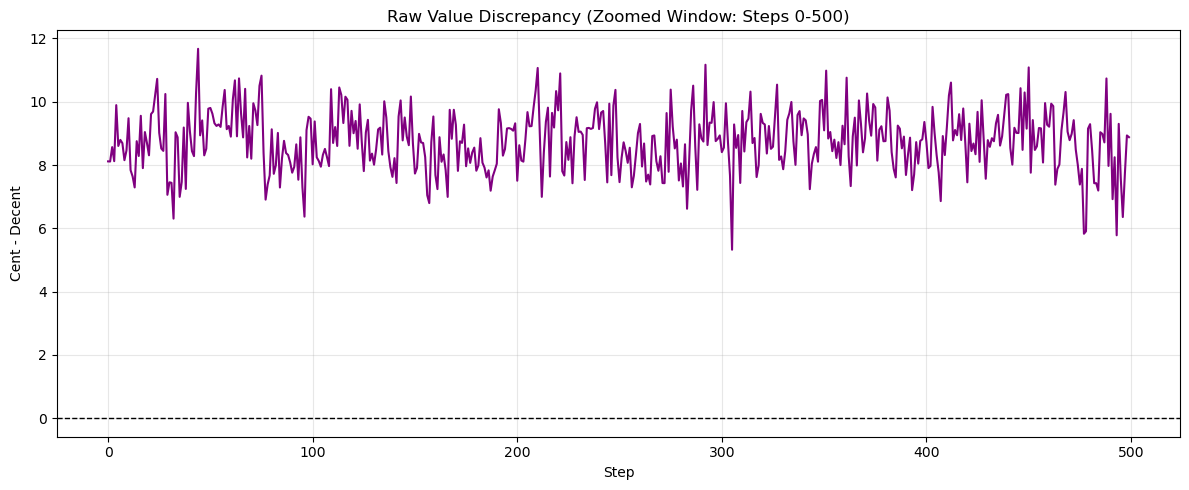

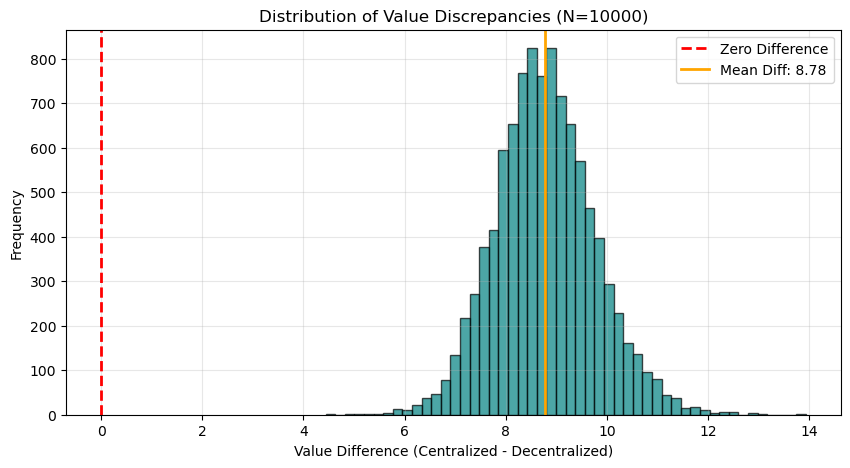


Processing 10000 steps...
Found 4664 disagreements (46.64%).
Writing full details to 'disagreement_full_log.txt'...
✅ Done. Log file saved.


In [7]:
# =============================================================================
# PHASE 5: VISUALIZATION & LOGGING
# =============================================================================

def plot_and_save_analysis(results, states, plot_start=0, plot_end=200, log_filename="disagreement_full_log.txt"):
    """
    1. Plots raw value difference for a specific window.
    2. Plots a HISTOGRAM of the difference over the whole run (Research Quality).
    3. Saves disagreements to file.
    """
    total_steps = len(results["step"])
    
    # Extract Arrays
    v_cent = np.array(results["cent_val"])
    v_dec = np.array(results["dec_val"])
    diff_all = v_cent - v_dec
    
    # --- PLOT 1: Trajectory Window (Zoomed In) ---
    start = max(0, plot_start)
    end = min(total_steps, plot_end)
    
    steps_window = results["step"][start:end]
    diff_window = diff_all[start:end]

    plt.figure(figsize=(12, 5))
    plt.plot(steps_window, diff_window, color='purple', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.title(f"Raw Value Discrepancy (Zoomed Window: Steps {start}-{end})")
    plt.ylabel("Cent - Decent")
    plt.xlabel("Step")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: Histogram of Differences (Statistical View) ---
    plt.figure(figsize=(10, 5))
    plt.hist(diff_all, bins=50, color='teal', alpha=0.7, edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label="Zero Difference")
    plt.axvline(np.mean(diff_all), color='orange', linestyle='-', linewidth=2, label=f"Mean Diff: {np.mean(diff_all):.2f}")
    plt.title(f"Distribution of Value Discrepancies (N={total_steps})")
    plt.xlabel("Value Difference (Centralized - Decentralized)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- LOGGING ---
    disagreement_count = sum(results["disagreement"])
    print(f"\nProcessing {total_steps} steps...")
    print(f"Found {disagreement_count} disagreements ({disagreement_count/total_steps*100:.2f}%).")
    print(f"Writing full details to '{log_filename}'...")
    
    with open(log_filename, "w") as f:
        f.write(f"=== DISAGREEMENT LOG ===\n")
        f.write(f"Steps Analyzed: {total_steps}\n")
        f.write(f"Total Disagreements: {disagreement_count}\n")
        f.write(f"Mean Value Difference: {np.mean(diff_all):.4f}\n")
        f.write("="*60 + "\n\n")
        
        for i in range(total_steps):
            if results["disagreement"][i]:
                # Extract info
                step_num = results["step"][i]
                agent_id = results["active_agent"][i]
                c_act = results["cent_action"][i].name
                d_act = results["dec_action"][i].name
                n_act = results["near_action"][i].name
                c_val = results["cent_val"][i]
                d_val = results["dec_val"][i]
                local_diff = c_val - d_val
                
                # Write Header
                f.write(f"STEP {step_num} | AGENT {agent_id} | Diff: {local_diff:.4f}\n")
                f.write(f"Centralized Action: {c_act:<10} (Val: {c_val:.4f})\n")
                f.write(f"Decentralized Action: {d_act:<10} (Val: {d_val:.4f})\n")
                f.write(f"Nearest (GT) Action:  {n_act:<10}\n")
                f.write("-" * 30 + "\n")
                
                # Write State Grid
                f.write(str(states[i]))
                f.write("\n\n" + "="*60 + "\n\n")

    print("✅ Done. Log file saved.")

# Plot specific window, but analyze ALL stats
plot_and_save_analysis(data, states, plot_start=0, plot_end=500)